In [1]:
import random
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

warnings.filterwarnings("ignore")

In [2]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif hasattr(torch, "xpu") and torch.xpu.is_available():
    DEVICE = torch.device("xpu")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)

DEVICE: mps


1. zip 파일 풀어서 데이터 폴더 정리
2. csv 파일 하나로 합치기
3. csv 파일에 거래일자로 정렬

## 라벨링 CSV 파일 합치기

Training과 Validation의 전자금융공동망·카드거래 CSV를 `for`문으로 각각 합칩니다. 결과는 각 `02.라벨링데이터` 폴더에 저장하며, 다시 실행하면 결과 파일을 덮어씁니다. 원본 파일과 행 순서를 유지하고 헤더는 한 번만 저장합니다.


In [4]:
# from pathlib import Path
# import csv
# import unicodedata

# # 한글 폴더명의 유니코드 표현이 달라도 실제 폴더를 찾습니다.
# def find_folder(parent, name):
#     for folder in parent.iterdir():
#         if folder.is_dir() and unicodedata.normalize("NFC", folder.name) == name:
#             return folder
#     raise FileNotFoundError(f"폴더를 찾을 수 없습니다: {parent / name}")

# # 프로젝트 루트에서 실행합니다.
# data_root = find_folder(
#     Path("data"), "이상 판별을 위한 금융거래 정보 및 사용자 패턴 합성데이터"
# )
# merge_results = []

# for split, prefix in [("Training", "TL"), ("Validation", "VL")]:
#     label_dir = data_root / split / "02.라벨링데이터"

#     for category in ["전자금융공동망", "카드거래"]:
#         source_dir = find_folder(label_dir, f"{prefix}_{category}")
#         csv_files = sorted(source_dir.glob("*.csv"))
#         if not csv_files:
#             raise FileNotFoundError(f"CSV 파일이 없습니다: {source_dir}")

#         # 합친 파일은 원본 하위 폴더가 아닌 라벨링데이터 폴더에 저장합니다.
#         output_path = label_dir / f"{prefix}_{category}.csv"
#         temp_path = output_path.with_suffix(".csv.tmp")
#         total_rows = 0
#         expected_header = None

#         # csv 모듈은 계좌번호의 앞자리 0 등을 문자열 그대로 보존합니다.
#         # 한 행씩 처리하므로 전체 데이터를 메모리에 올리지 않습니다.
#         try:
#             with temp_path.open("w", encoding="utf-8-sig", newline="") as output:
#                 writer = csv.writer(output)
#                 for csv_path in csv_files:
#                     with csv_path.open("r", encoding="utf-8-sig", newline="") as source:
#                         reader = csv.reader(source)
#                         header = next(reader)
#                         if expected_header is None:
#                             expected_header = header
#                             writer.writerow(header)  # 헤더는 한 번만 저장
#                         elif header != expected_header:
#                             raise ValueError(f"컬럼 구성이 다릅니다: {csv_path}")

#                         for row in reader:
#                             if not row:  # 빈 줄 제외
#                                 continue
#                             if len(row) != len(expected_header):
#                                 raise ValueError(f"컬럼 수 오류: {csv_path}, 줄 {reader.line_num}")
#                             writer.writerow(row)
#                             total_rows += 1
#             temp_path.replace(output_path)
#         finally:
#             if temp_path.exists():
#                 temp_path.unlink()

#         merge_results.append((output_path, len(csv_files), total_rows))
#         print(f"{split} / {output_path.name}: {len(csv_files)}개 파일 → {total_rows:,}행")


## 데이터 경로 설정 및 확인
우선 전자금융거래만 적용


In [5]:
DATA_PATH_TL = './data/이상 판별을 위한 금융거래 정보 및 사용자 패턴 합성데이터/Training/02.라벨링데이터/TL_전자금융공동망.csv' 
DATA_PATH_VL = './data/이상 판별을 위한 금융거래 정보 및 사용자 패턴 합성데이터/Validation/02.라벨링데이터/VL_전자금융공동망.csv'

# 학습 데이터
df_train = pd.read_csv(
    DATA_PATH_TL,
    encoding="utf-8-sig"
)

# 검증 데이터
df_validation = pd.read_csv(
    DATA_PATH_VL,
    encoding="utf-8-sig"
)


In [6]:
df_train.head()

,출금계좌일련번호,입금계좌일련번호,출금금융회사일련번호,입금금융회사일련번호,자금구분,거래금액,거래시간대,매체구분,거래일자,이상거래유형,이상거래여부,이상거래설명
0,9000000004232558,9000000004297579,134,131,0,30000,9,4,20210928,NaN,0,NaN
1,9000000000014758,9000000001056571,134,155,0,40000,9,2,20210927,NaN,0,NaN
2,9000000004240556,9000000004387266,155,134,0,300000,15,2,20210917,NaN,0,NaN
3,9000000004230234,9000000004286770,133,159,0,30000,9,4,20210904,NaN,0,NaN
4,9000000004229183,9000000004259755,131,159,0,30000,12,4,20210910,NaN,0,NaN


In [7]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941428 entries, 0 to 3941427
Data columns (total 12 columns):
 #   Column      Dtype  
---  ------      -----  
 0   출금계좌일련번호    int64  
 1   입금계좌일련번호    int64  
 2   출금금융회사일련번호  int64  
 3   입금금융회사일련번호  int64  
 4   자금구분        int64  
 5   거래금액        int64  
 6   거래시간대       int64  
 7   매체구분        int64  
 8   거래일자        int64  
 9   이상거래유형      float64
 10  이상거래여부      int64  
 11  이상거래설명      str    
dtypes: float64(1), int64(10), str(1)
memory usage: 360.8 MB


## 입금계좌 일련번호 중복 확인

전자금융공동망의 Training과 Validation을 각각 확인합니다. 같은 계좌가 여러 거래에서 사용된 경우도 중복으로 집계되므로, 계좌번호 중복이 곧 중복 거래를 의미하지는 않습니다.


In [8]:
# 위 CSV 병합 셀에서 설정한 data_root를 사용합니다.
# 카드거래 데이터에는 입금계좌일련번호 컬럼이 없으므로 전자금융공동망만 확인합니다.
account_column = "입금계좌일련번호"
duplicate_account_counts = {}

for split, prefix in [("Training", "TL"), ("Validation", "VL")]:
    csv_path = f'./data/이상 판별을 위한 금융거래 정보 및 사용자 패턴 합성데이터/{split}/02.라벨링데이터/{prefix}_전자금융공동망.csv'
    # 필요한 컬럼만 읽고, 계좌번호를 문자열로 유지합니다.
    accounts = pd.read_csv(
        csv_path,
        usecols=[account_column],
        dtype={account_column: "string"},
        encoding="utf-8-sig",
        keep_default_na=False,
    )[account_column]

    # 빈 계좌번호는 중복 판별에서 제외합니다.
    missing_mask = accounts.str.strip().eq("")
    valid_accounts = accounts[~missing_mask]
    account_counts = valid_accounts.value_counts()
    duplicate_counts = account_counts[account_counts > 1]
    duplicate_account_counts[split] = duplicate_counts

    print(f"\n[{split}] 입금계좌 일련번호 중복 확인")
    print(f"전체 행 수: {len(accounts):,}")
    print(f"빈 계좌번호 행 수: {missing_mask.sum():,}")
    print(f"중복 여부: {valid_accounts.duplicated().any()}")
    print(f"고유 계좌번호 수: {valid_accounts.nunique():,}")
    print(f"2번 이상 등장한 계좌번호 수: {len(duplicate_counts):,}")
    print(f"중복 계좌번호에 해당하는 전체 행 수: {duplicate_counts.sum():,}")
    print(f"첫 등장 이후 중복 행 수: {valid_accounts.duplicated().sum():,}")
    print("등장 횟수가 가장 많은 중복 계좌번호 상위 10개:")
    print(duplicate_counts.head(10).rename("등장횟수").to_string())

# 전체 중복 계좌번호와 횟수 조회:
# duplicate_account_counts["Training"]
# duplicate_account_counts["Validation"]



[Training] 입금계좌 일련번호 중복 확인
전체 행 수: 3,941,428
빈 계좌번호 행 수: 0
중복 여부: True
고유 계좌번호 수: 379,135
2번 이상 등장한 계좌번호 수: 190,306
중복 계좌번호에 해당하는 전체 행 수: 3,752,599
첫 등장 이후 중복 행 수: 3,562,293
등장 횟수가 가장 많은 중복 계좌번호 상위 10개:
입금계좌일련번호
9000000004382602    21431
9000000001279469    21233
9000000000589184    16246
9000000004259541    15795
9000000003153016    13712
9000000004409879    13699
9000000004387144    10937
9000000002478446    10505
9000000004420861    10110
9000000004431530    10012

[Validation] 입금계좌 일련번호 중복 확인
전체 행 수: 492,678
빈 계좌번호 행 수: 0
중복 여부: True
고유 계좌번호 수: 114,442
2번 이상 등장한 계좌번호 수: 40,867
중복 계좌번호에 해당하는 전체 행 수: 419,103
첫 등장 이후 중복 행 수: 378,236
등장 횟수가 가장 많은 중복 계좌번호 상위 10개:
입금계좌일련번호
9000000001279469    2690
9000000004382602    2689
9000000000589184    2016
9000000004259541    1953
9000000004409879    1686
9000000003153016    1684
9000000004387144    1401
9000000003994064    1276
9000000004420861    1244
9000000002478446    1241


## 출금계좌끼리 그룹으로 묶은 후 거래일자, 거래시간대로 정렬

In [9]:
# 출금계좌별 정렬: 데이터 로딩 셀을 먼저 실행하세요.
def sort_account_transactions(df, include_time=False):
    columns = ["출금계좌일련번호", "거래일자"]
    if include_time:
        columns.append("거래시간대")

    def sort_key(series):
        if series.name == "거래일자":
            return pd.to_datetime(series.astype("string"), format="%Y%m%d")
        if series.name == "거래시간대":
            return pd.to_numeric(series, errors="raise")
        return series

    return df.sort_values(
        columns, key=sort_key, kind="stable", na_position="last"
    ).reset_index(drop=True)

# 1. 출금계좌 → 거래일자 순 (오름차순)
df_train_by_date = sort_account_transactions(df_train)
df_validation_by_date = sort_account_transactions(df_validation)

# 2. 출금계좌 → 거래일자 → 시간대 순 (오름차순)
df_train_by_datetime = sort_account_transactions(df_train, include_time=True)
df_validation_by_datetime = sort_account_transactions(df_validation, include_time=True)

# 계좌별 그룹: 각 그룹 안에서도 위 정렬 순서가 유지됩니다.
train_groups_by_date = df_train_by_date.groupby("출금계좌일련번호", sort=False, dropna=False) # 계좌별로 거래 묶기
validation_groups_by_date = df_validation_by_date.groupby("출금계좌일련번호", sort=False, dropna=False)
train_groups_by_datetime = df_train_by_datetime.groupby("출금계좌일련번호", sort=False, dropna=False)
validation_groups_by_datetime = df_validation_by_datetime.groupby("출금계좌일련번호", sort=False, dropna=False)

# 첫 계좌의 거래를 두 정렬 방식으로 비교
example_account = df_train_by_datetime["출금계좌일련번호"].dropna().iloc[0]
print("출금계좌:", example_account)
print("거래일자 → 시간대 순")
display(train_groups_by_datetime.get_group(example_account).head(10))


출금계좌: 9000000000000002
거래일자 → 시간대 순


,출금계좌일련번호,입금계좌일련번호,출금금융회사일련번호,입금금융회사일련번호,자금구분,거래금액,거래시간대,매체구분,거래일자,이상거래유형,이상거래여부,이상거래설명
0,9000000000000002,9000000000045271,102,146,0,300000,9,1,20210917,NaN,0,NaN
1,9000000000000002,9000000004133133,102,156,0,300000,18,1,20211003,NaN,0,NaN
2,9000000000000002,9000000000045271,102,146,0,300000,9,1,20211018,NaN,0,NaN
3,9000000000000002,9000000003727796,102,134,0,300000,18,1,20211019,NaN,0,NaN
4,9000000000000002,9000000003383254,102,160,0,300000,15,1,20211026,NaN,0,NaN
5,9000000000000002,9000000001339199,102,155,0,300000,15,1,20211107,NaN,0,NaN
6,9000000000000002,9000000003069143,102,130,0,300000,9,1,20211110,NaN,0,NaN
7,9000000000000002,9000000000978332,102,155,0,300000,9,1,20211205,NaN,0,NaN
8,9000000000000002,9000000002613833,102,157,0,300000,18,1,20211221,NaN,0,NaN
9,9000000000000002,9000000001138163,102,134,0,300000,9,1,20211224,NaN,0,NaN


이상거래여부 값: [0 1]


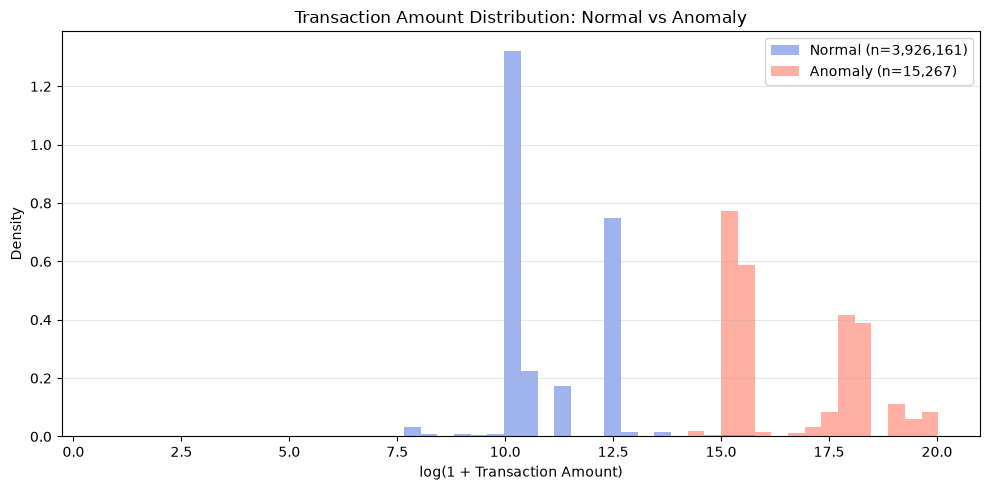

In [10]:
# 실제 라벨 값 확인 후 아래 값을 맞춰주세요.
print("이상거래여부 값:", df_train["이상거래여부"].unique())

NORMAL_LABEL = 0    # 정상 라벨
ANOMALY_LABEL = 1   # 이상 라벨

amount = pd.to_numeric(df_train["거래금액"], errors="coerce")
label = df_train["이상거래여부"]

normal = amount[(label == NORMAL_LABEL) & amount.ge(0)].dropna()
anomaly = amount[(label == ANOMALY_LABEL) & amount.ge(0)].dropna()

if normal.empty or anomaly.empty:
    raise ValueError("정상·이상 라벨 값을 확인하세요.")

# log1p: 거래금액이 0이어도 변환 가능
normal_log = np.log1p(normal)
anomaly_log = np.log1p(anomaly)

# 두 그룹에 동일한 구간 적용
bins = np.linspace(
    min(normal_log.min(), anomaly_log.min()),
    max(normal_log.max(), anomaly_log.max()),
    51,
)

fig, ax = plt.subplots(figsize=(10, 5))

# 그룹별 건수가 달라도 분포 형태를 비교하도록 밀도로 표시
ax.hist(
    normal_log, bins=bins, density=True,
    alpha=0.5, color="royalblue",
    label=f"Normal (n={len(normal):,})",
)
ax.hist(
    anomaly_log, bins=bins, density=True,
    alpha=0.5, color="tomato",
    label=f"Anomaly (n={len(anomaly):,})",
)

ax.set_title("Transaction Amount Distribution: Normal vs Anomaly")
ax.set_xlabel("log(1 + Transaction Amount)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
FEATURES = ["거래금액", "거래시간대"]
target = "이상거래여부"
SEQUENCE_LENGTH = 20

In [12]:
def add_features(df):
    df = df.copy()  # 출금계좌 → 날짜 → 시간대 정렬된 데이터

    # 현재 거래를 제외한 이전 최대 20건의 평균 금액
    previous_mean = df.groupby("출금계좌일련번호")["거래금액"].transform(
        lambda s: s.shift(1).rolling(20, min_periods=1).mean()
    )

    # 이전 평균이 없거나 0이면 비율을 계산할 수 없으므로 0으로 채움
    df["이전평균대비금액"] = (
        df["거래금액"]
        .div(previous_mean.where(previous_mean > 0))
        .fillna(0)
    )

    # 시간대를 원형으로 표현: 23시와 0시가 가깝도록 처리
    hour = pd.to_numeric(df["거래시간대"])
    df["시간_sin"] = np.sin(2 * np.pi * hour / 24)
    df["시간_cos"] = np.cos(2 * np.pi * hour / 24)

    return df

df_train_by_datetime = add_features(df_train_by_datetime)
df_validation_by_datetime = add_features(df_validation_by_datetime)

FEATURES = [
    "거래금액",
    "이전평균대비금액",
    "시간_sin",
    "시간_cos",
]

### 스케일링

In [13]:
scaler = StandardScaler()

scaler.fit(df_train_by_datetime[FEATURES])

# 전체 데이터를 미리 변환해두면 계좌마다 transform을 반복하지 않아도 됨
train_scaled = df_train_by_datetime.copy()
validation_scaled = df_validation_by_datetime.copy()

train_scaled[FEATURES] = scaler.transform(
    df_train_by_datetime[FEATURES]
)

validation_scaled[FEATURES] = scaler.transform(
    df_validation_by_datetime[FEATURES]
)

## 시퀀스 만들기
- 계좌별로 만들기
(3_LSTM과 GRU.ipynb에서는 과거 입력으로 다음 시점의 값을 예측함)
(거래 이상여부를 탐지하려면 현재 거래를 입력에 포함해야 하니까 2_RNN.ipynb의 슬라이싱 방법 적용)

In [15]:
def make_account_sequences(df, features, target, sequence_length):
    X_seq = []
    y_seq = []

    for account, account_df in df.groupby(
        "출금계좌일련번호", sort=False
    ):
        X = account_df[features].to_numpy(dtype=np.float32)
        y = account_df[target].to_numpy(dtype=np.float32)

        for i in range(sequence_length - 1, len(account_df)):
            start = i - sequence_length + 1

            # 이전 19건 + 현재 거래 1건
            X_seq.append(X[start:i + 1])

            # 현재 거래의 정상·이상 라벨
            y_seq.append([y[i]])

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
    )

In [16]:
X_train, y_train = make_account_sequences(
    train_scaled, FEATURES, target, SEQUENCE_LENGTH
)

X_val, y_val = make_account_sequences(
    validation_scaled, FEATURES, target, SEQUENCE_LENGTH
)

print("Train: ", X_train.shape, y_train.shape)
print("Validation: ", X_val.shape, y_val.shape)

if len(X_train) == 0 or len(X_val)==0:
    raise ValueError("계좌별 거래 수가 충분하지 않아 시퀀스를 만들 수 없습니다. SEQUENCE_LENGTH를 줄이거나 데이터셋을 확인하세요.")

Train:  (3417274, 20, 4) (3417274, 1)
Validation:  (178344, 20, 4) (178344, 1)


In [17]:
class TransactionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(TransactionDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TransactionDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

In [19]:
xb, yb = next(iter(train_loader))
print(xb.shape)
print(yb.shape)

torch.Size([64, 20, 4])
torch.Size([64, 1])


In [20]:
class PowerLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, 
                            dropout= dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)

    # 순전파
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]
        prediction = self.fc(last_hidden)
        return prediction

In [21]:
model = PowerLSTM(input_size=len(FEATURES)).to(DEVICE)
model

PowerLSTM(
  (lstm): LSTM(4, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [22]:
model.eval()

with torch.no_grad():
    logits = model(xb.to(DEVICE))
    probabilities = torch.sigmoid(logits)

    # 처음에는 0.5를 기준으로 확인
    predictions = (probabilities >= 0.5).int()

### 학습

In [31]:
positive_count = int((y_train == 1).sum())
negative_count = int((y_train == 0).sum())

print("정상:", negative_count)
print("이상:", positive_count)

if positive_count == 0 or negative_count == 0:
    raise ValueError("학습 정답에 정상과 이상 거래가 모두 필요합니다.")

# 기존 가중치의 절반으로 비교 실험
WEIGHT_FACTOR = 0.5

weight = max(
    1.0,
    (negative_count / positive_count) * WEIGHT_FACTOR,
)

pos_weight = torch.tensor(
    [weight],
    dtype=torch.float32,
    device=DEVICE,
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("적용한 pos_weight:", pos_weight.item())

정상: 3404718
이상: 12556
적용한 pos_weight: 135.58131408691406


In [24]:
# train_loader: 계좌별 시퀀스로 만든 학습 데이터
# model: LSTM ahepf
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

MAX_EPOCHS = 20
PATIENCE = 8
CLIP_NORM = 1.0

In [32]:
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    # 초기화
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count

In [33]:
best_val_loss = float("inf") # 줄여가는 방식
best_state = None
wait = 0

train_history = []
val_history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train() # 학습
    train_loss_sum = 0.0
    train_count = 0
    
    for xb, yb in train_loader: # 로더에서 꺼냄
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_NORM) # 폭주 방지
        optimizer.step()
        batch_size = xb.size(0)
        train_loss_sum += (loss.item() * batch_size)
        train_count += batch_size
    train_loss = (train_loss_sum / train_count)
    val_loss = evaluate_loss(model, val_loader, criterion, DEVICE)
    train_history.append(train_loss)
    val_history.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    print(
        f"Epoch {epoch:02d} | "
        f"Train {train_loss:.6f} | "
        f"Valid {val_loss:.6f}"
    )

    if wait >= PATIENCE:
        print(f"Early stopping: epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Best Validation Loss: {best_val_loss:.6f}")


Epoch 01 | Train 0.039574 | Valid 0.078866
Epoch 02 | Train 0.039760 | Valid 0.081563
Epoch 03 | Train 0.038999 | Valid 0.079887
Epoch 04 | Train 0.039424 | Valid 0.084892
Epoch 05 | Train 0.039271 | Valid 0.078512
Epoch 06 | Train 0.038587 | Valid 0.083458
Epoch 07 | Train 0.039025 | Valid 0.077411
Epoch 08 | Train 0.039087 | Valid 0.078171
Epoch 09 | Train 0.040984 | Valid 0.086219
Epoch 10 | Train 0.040953 | Valid 0.090890
Epoch 11 | Train 0.040215 | Valid 0.081735
Epoch 12 | Train 0.038665 | Valid 0.094603
Epoch 13 | Train 0.037896 | Valid 0.105779
Epoch 14 | Train 0.039355 | Valid 0.108383
Epoch 15 | Train 0.039187 | Valid 0.092668
Early stopping: epoch 15
Best Validation Loss: 0.077411


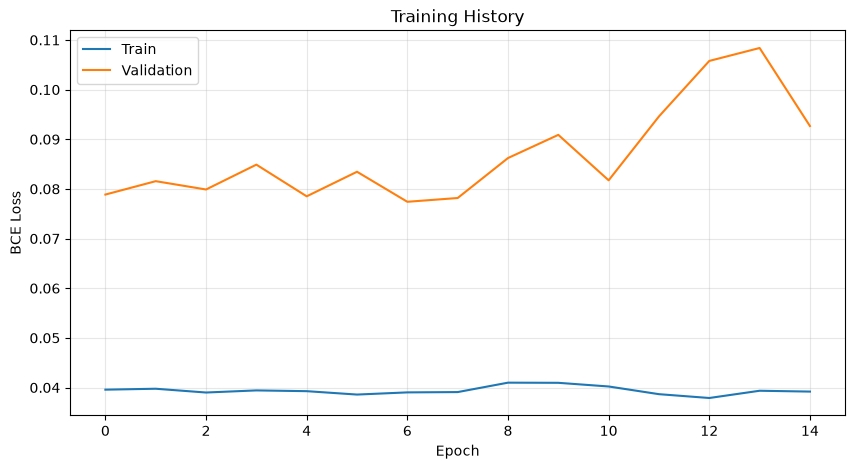

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(train_history, label="Train")
plt.plot(val_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

현재 손실함수: BCEWithLogitsLoss()

분류 기준값: 0.5
실제 이상 거래: 988건
예측 이상 거래: 3,223건

              precision    recall  f1-score   support

      Normal     1.0000    0.9874    0.9936    177356
     Anomaly     0.3044    0.9929    0.4659       988

    accuracy                         0.9874    178344
   macro avg     0.6522    0.9901    0.7298    178344
weighted avg     0.9961    0.9874    0.9907    178344

정상을 정상으로 판단: 175,114건
정상을 이상으로 오인: 2,242건
이상을 정상으로 놓침: 7건
이상을 이상으로 탐지: 981건


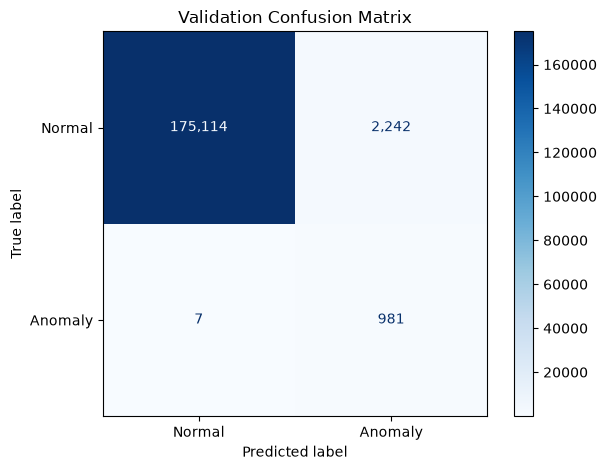

In [35]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# 1. 실제 사용한 손실함수 확인
print("현재 손실함수:", criterion)

if not isinstance(criterion, torch.nn.BCEWithLogitsLoss):
    print("확인 필요: 이상거래 이진 분류에는 BCEWithLogitsLoss 사용을 권장합니다.")

# 2. Validation 전체 예측
# 모델은 Sigmoid를 적용하지 않은 logits를 출력해야 합니다.
model.eval()

all_probabilities = []
all_targets = []

with torch.no_grad():
    for xb, yb in val_loader:
        logits = model(xb.to(DEVICE))
        probabilities = torch.sigmoid(logits)

        all_probabilities.append(probabilities.cpu().reshape(-1).numpy())
        all_targets.append(yb.cpu().reshape(-1).numpy())

if not all_targets:
    raise ValueError("Validation DataLoader에 데이터가 없습니다.")

y_prob = np.concatenate(all_probabilities)
y_true = np.concatenate(all_targets)

if not np.isin(y_true, [0, 1]).all():
    raise ValueError("정답 라벨이 정상=0, 이상=1인지 확인하세요.")

y_true = y_true.astype(int)

THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)

# 3. 클래스별 Precision, Recall, F1
print(f"\n분류 기준값: {THRESHOLD}")
print(f"실제 이상 거래: {np.sum(y_true == 1):,}건")
print(f"예측 이상 거래: {np.sum(y_pred == 1):,}건\n")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Normal", "Anomaly"],
        digits=4,
        zero_division=0,
    )
)

# 4. 혼동행렬
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"정상을 정상으로 판단: {tn:,}건")
print(f"정상을 이상으로 오인: {fp:,}건")
print(f"이상을 정상으로 놓침: {fn:,}건")
print(f"이상을 이상으로 탐지: {tp:,}건")

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"],
).plot(cmap="Blues", values_format=",")

plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()